In [26]:
%run _bootstrap_dev.ipynb


Runtime dev completato.


# Lazy Portfolio Analyst
Flusso: frequency selection → posizionamento rispetto alla frontiera
efficiente (diagnostico) → backtest PTF → validazione statistica.

La frontiera efficiente è uno strumento diagnostico: i suoi pesi
"ottimali" sono stimati in-sample sull'intero storico e non vanno
adottati come allocazione — sono affetti da overfitting strutturale
(si veda §5).

## §1 — Configurazione

In [27]:
# Portafoglio da analizzare (definiti in l_portfolios.py)
# my_portfolio       = greta_base_spy_portfolio_etf_ita
my_portfolio       = greta_alt_emdiv_test
# my_portfolio_title = "Gretchen S&P 500 Core-Engine - Fiduciaria"
my_portfolio_title = "Gretchen S&P 500 Core-Engine - Alternative Test"

# Parametri analisi
start_date = '2016-01-01'   # inizio backtest
end_date   = None           # None = oggi
benchmark  = 'SPY'
init_cash  = 100_000
fees       = 0.001
years      = 10             # finestra frontiera efficiente (anni)

## §2 — Frequency Selection
Testa W/M/Q/Y/None e seleziona la frequenza con Sharpe massimo.
Cambia `freq_selection_metric` per usare 'cagr' | 'total_return' | 'max_dd'.

In [28]:
freqs = ['W', 'M', 'Q', 'Y', None]
_rows = []
for _freq in freqs:
    _pf = run_bh_backtest(my_portfolio, start_date, end_date,
                          init_cash, fees, _freq)
    _eq = _pf.value()
    if isinstance(_eq, pd.DataFrame): _eq = _eq.iloc[:,0]
    _eq = _eq.dropna()
    _yrs = len(_eq) / 252
    _cagr = (_eq.iloc[-1]/_eq.iloc[0])**(1/_yrs)-1 if _yrs > 0 else np.nan
    _rows.append({
        'Freq'        : _freq if _freq is not None else 'BH',
        'Sharpe'      : float(_pf.sharpe_ratio()),
        'CAGR%'       : round(_cagr * 100, 2),
        'TotalReturn%': round(float(_pf.total_return()) * 100, 2),
        'MaxDD%'      : round(abs(float(_pf.max_drawdown())) * 100, 2),
    })
freq_df = pd.DataFrame(_rows)
my_display(freq_df, title="Confronto frequenze di ribilanciamento")

# Selezione automatica: max Sharpe (modifica idxmax → idxmin per MaxDD%)
freq_selection_metric = 'Sharpe'
best_label = freq_df.loc[freq_df[freq_selection_metric].idxmax(), 'Freq']
best_freq  = None if best_label == 'BH' else best_label
print(f"\n✅ Frequenza ottimale ({freq_selection_metric}): {best_label}")

Confronto frequenze di ribilanciamento


,Freq,Sharpe,CAGR%,TotalReturn%,MaxDD%
0,W,1.184108,13.28,266.70,25.33
1,M,1.188697,13.19,263.78,24.90
2,Q,1.193037,13.19,263.78,24.45
3,Y,1.203710,13.12,261.27,24.17
4,BH,1.151250,13.51,274.69,26.29



✅ Frequenza ottimale (Sharpe): Y


## §3 — Posizionamento rispetto alla frontiera efficiente (diagnostico)

Mostra dove si colloca il PTF proposto rispetto allo spazio
rischio/rendimento stimato storicamente. Non è un suggerimento di
allocazione: i punti della frontiera (Min Vol, Max Sharpe, Max Return)
sono ottimizzati in-sample e quindi inevitabilmente overfit — si veda
la nota in §5.

**Legenda colonne:**
- `Return` / `Volatility` / `Sharpe` — valori teorici stimati da
  media storica e covarianza (PyPortfolioOpt, in-sample)
- `Real Return` / `Real Volatility` / `Real Sharpe` — valori
  effettivi misurati sul backtest reale nel periodo selezionato

[*********************100%***********************]  5 of 5 completed


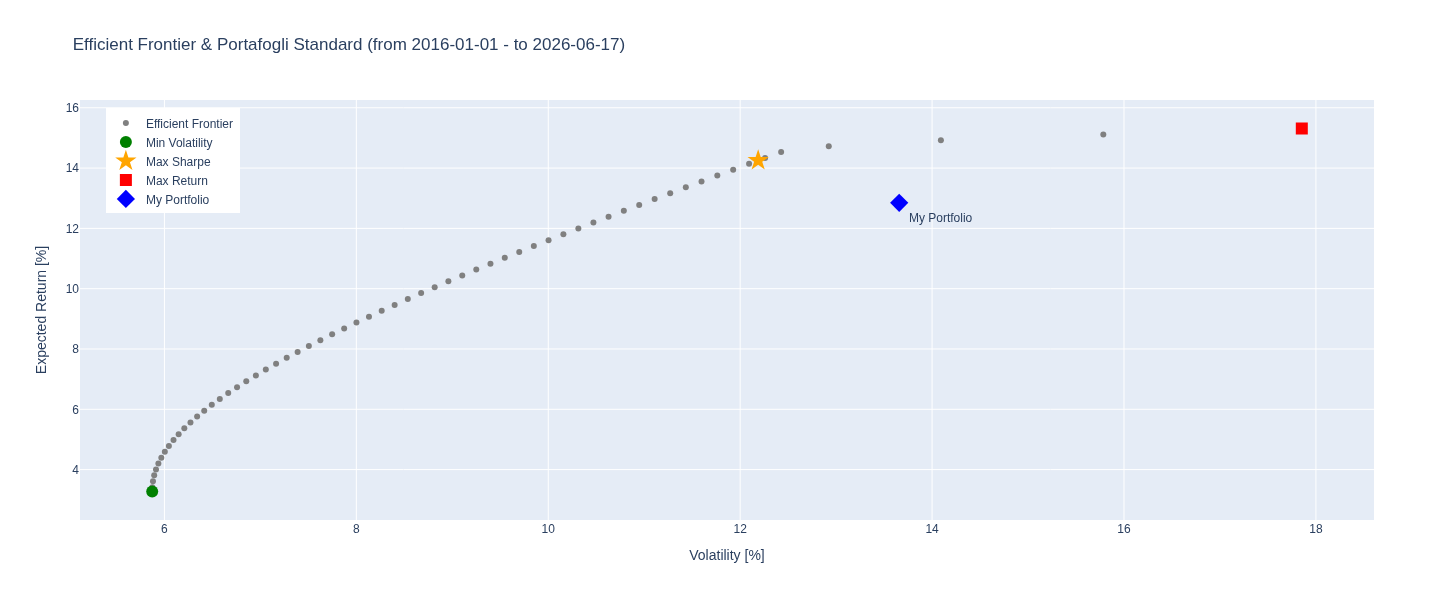

,EEM,GLD,IEF,SPY,TLH,Return,Volatility,Sharpe,Real Return,Real Volatility,Real Sharpe
Min Vol,0.0061,0.0019,0.8486,0.1435,0.00,3.27,5.87,0.56,NaN,NaN,NaN
Max Sharpe,0.0000,0.5106,0.0219,0.4674,0.00,14.25,12.19,1.17,NaN,NaN,NaN
Max Return,0.0000,0.0000,0.0000,1.0000,0.00,15.31,17.85,0.86,NaN,NaN,NaN
My Portfolio,0.1500,0.1500,0.0500,0.6000,0.05,12.85,13.66,0.94,20.14,17.22,1.15



Posizionamento PTF proposto vs frontiera (diagnostico):
  My Portfolio  — Sharpe: 0.94  Return: 12.85%  Vol: 13.66%
  Max Sharpe pt — Sharpe: 1.17  Return: 14.25%  Vol: 12.19%
  ⚠️  Il punto Max Sharpe è in-sample — vedi §5 prima di interpretarlo


In [30]:
my_tickers = list(my_portfolio.keys())
my_weights = list(my_portfolio.values())

fig_frontier, df_special = efficient_frontier_pypfopt(
    tickers=my_tickers,
    years=years,
    my_weights=my_weights,
    n_points=80,
    weight_bounds=(0, 1),
    show_plot=True,
    interactive=True,
    print_weights=True,
)
# fig_frontier.show()

# Pesi ottimali Max Sharpe
_metric_cols = {'Return', 'Volatility', 'Sharpe',
                'Real Return', 'Real Volatility', 'Real Sharpe'}
_weight_cols = [c for c in df_special.columns if c not in _metric_cols]
optimal_weights = df_special.loc['Max Sharpe', _weight_cols].to_dict()

print("\nPosizionamento PTF proposto vs frontiera (diagnostico):")
print(f"  My Portfolio  — Sharpe: {df_special.loc['My Portfolio','Sharpe']:.2f}"
      f"  Return: {df_special.loc['My Portfolio','Return']:.2f}%"
      f"  Vol: {df_special.loc['My Portfolio','Volatility']:.2f}%")
print(f"  Max Sharpe pt — Sharpe: {df_special.loc['Max Sharpe','Sharpe']:.2f}"
      f"  Return: {df_special.loc['Max Sharpe','Return']:.2f}%"
      f"  Vol: {df_special.loc['Max Sharpe','Volatility']:.2f}%")
print("  ⚠️  Il punto Max Sharpe è in-sample — vedi §5 prima di interpretarlo")
# optimal_weights resta calcolato per riferimento (usato in §5 nota), non come allocazione consigliata

## §4 — Backtest PTF proposto
Analisi completa con la frequenza ottimale selezionata in §2.

📈 Statistiche Portfolio Gretchen S&P 500 Core-Engine - Alternative Test - Frequenza Y (2016-01-04 → 2026-06-16)

================= STATISTICHE ==================


,
Periodo,2016-01-04 -> 2026-06-16
Benchmark source,external
Benchmark name,SPY
Importo investito (€),100000.00
Valore patrimoniale netto (€),361265.85
Giorni di trading,2628
Ritorno totale,261.27%
CAGR,13.11%
Max Drawdown,24.17%
Volatilità annua,15.87%



================= SINTESI ==================
╒═════════════════════╤═══════════════════════╤══════════════╤════════════════╤═══════════════════════╤══════════════════════╤══════════════════════╤═════════════════════════════╕
│  Importo investito  │  Valore finale netto  │  CAGR (252)  │  Max Drawdown  │  Deviazione standard  │  Rapporto di Sharpe  │  Operazioni al mese  │  Durata minima in guadagno  │
╞═════════════════════╪═══════════════════════╪══════════════╪════════════════╪═══════════════════════╪══════════════════════╪══════════════════════╪═════════════════════════════╡
│       100000        │        361266         │    13.11%    │     24.17%     │        15.87%         │         0.85         │         0.37         │             649             │
╘═════════════════════╧═══════════════════════╧══════════════╧════════════════╧═══════════════════════╧══════════════════════╧══════════════════════╧═════════════════════════════╛


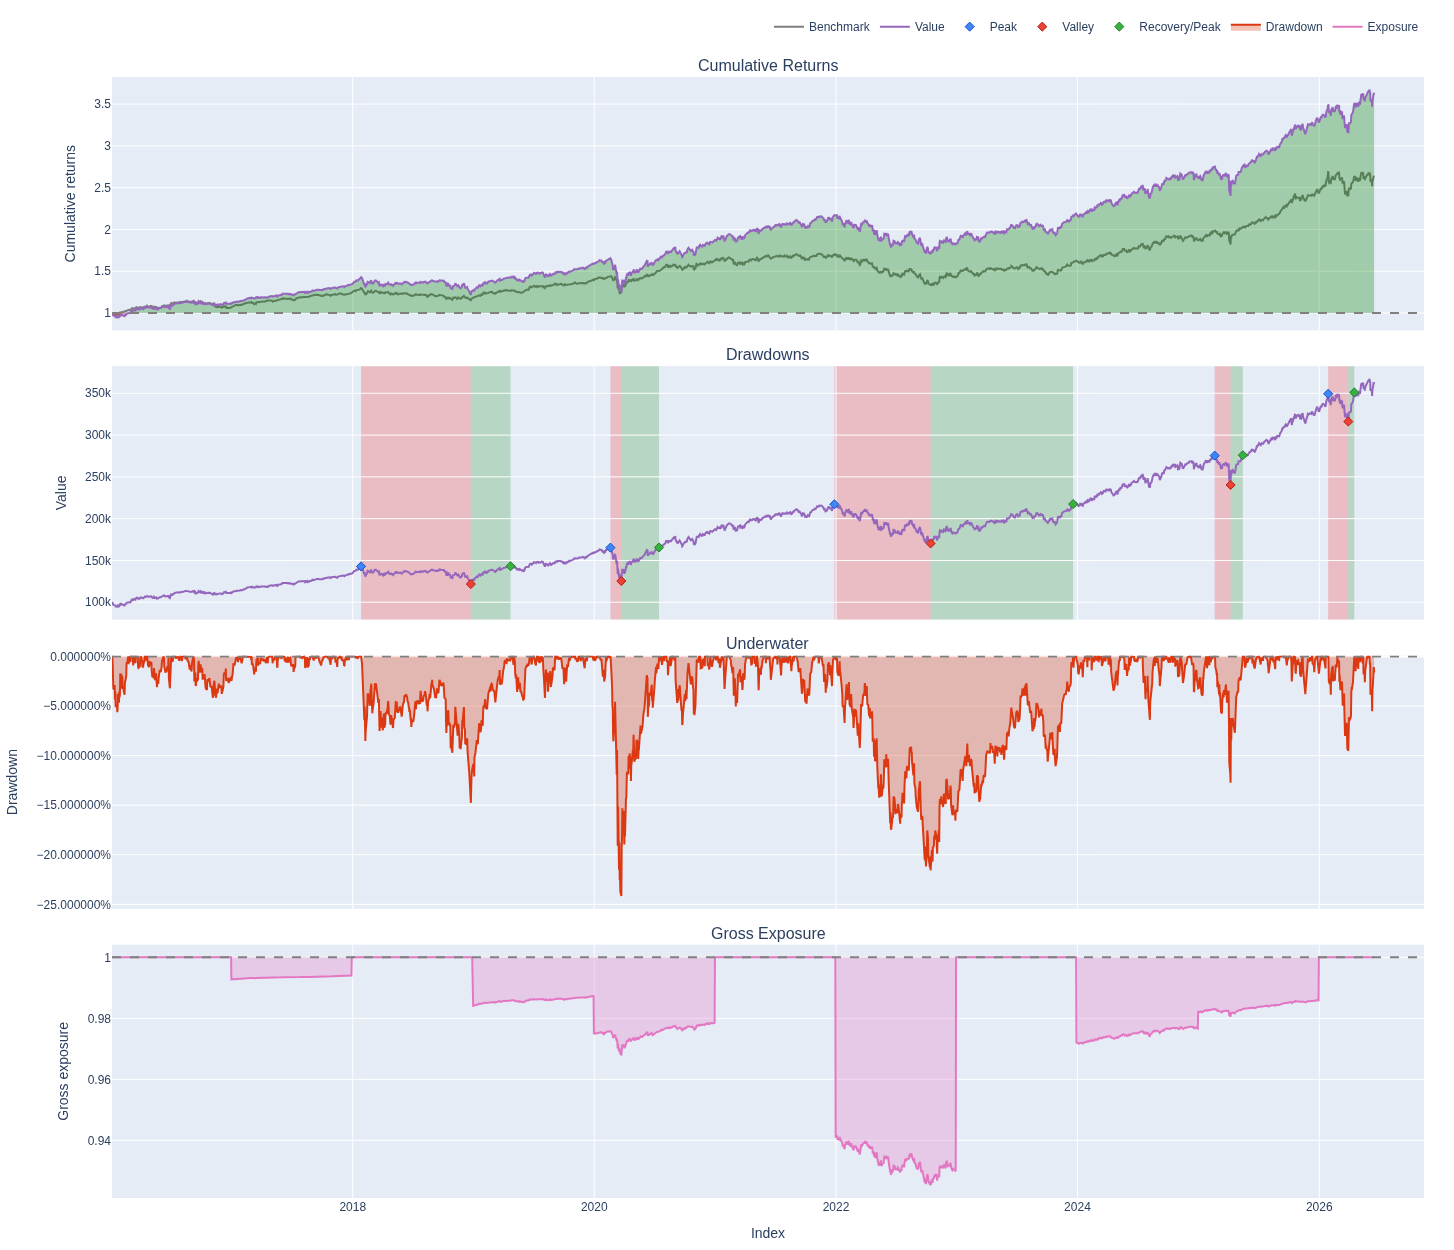

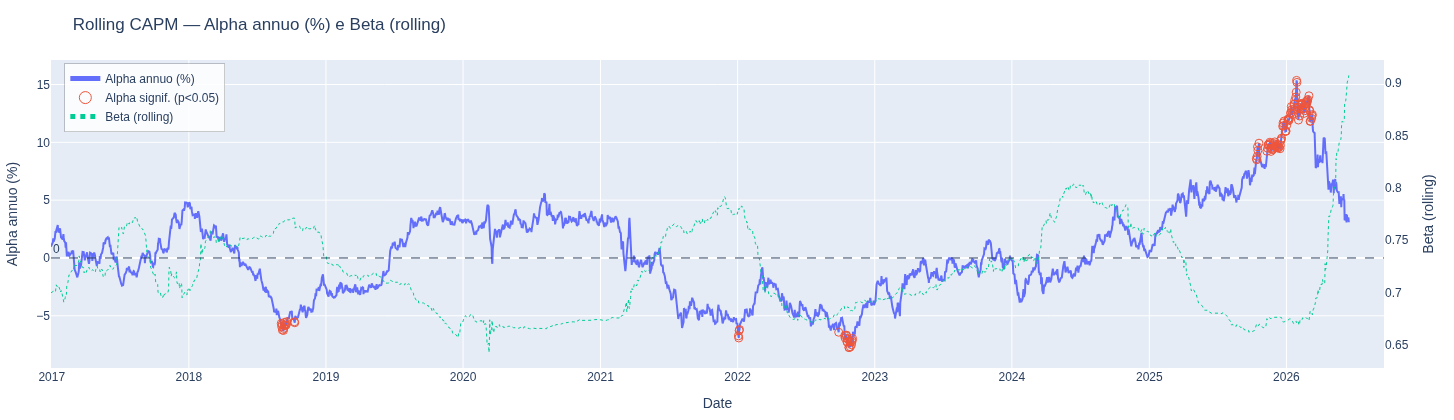


================= ANALISI ALPHA ==================
Alpha positivo ma non significativo. Beta b=0.71. alpha_ann=1.43%, T=1.18, P=2.39e-01, TE=0.039, Obs=2628.
Rolling alpha in miglioramento. Ultimo=3.09%, mediana=0.15%. p<0.05 nel 5.2% dei giorni.


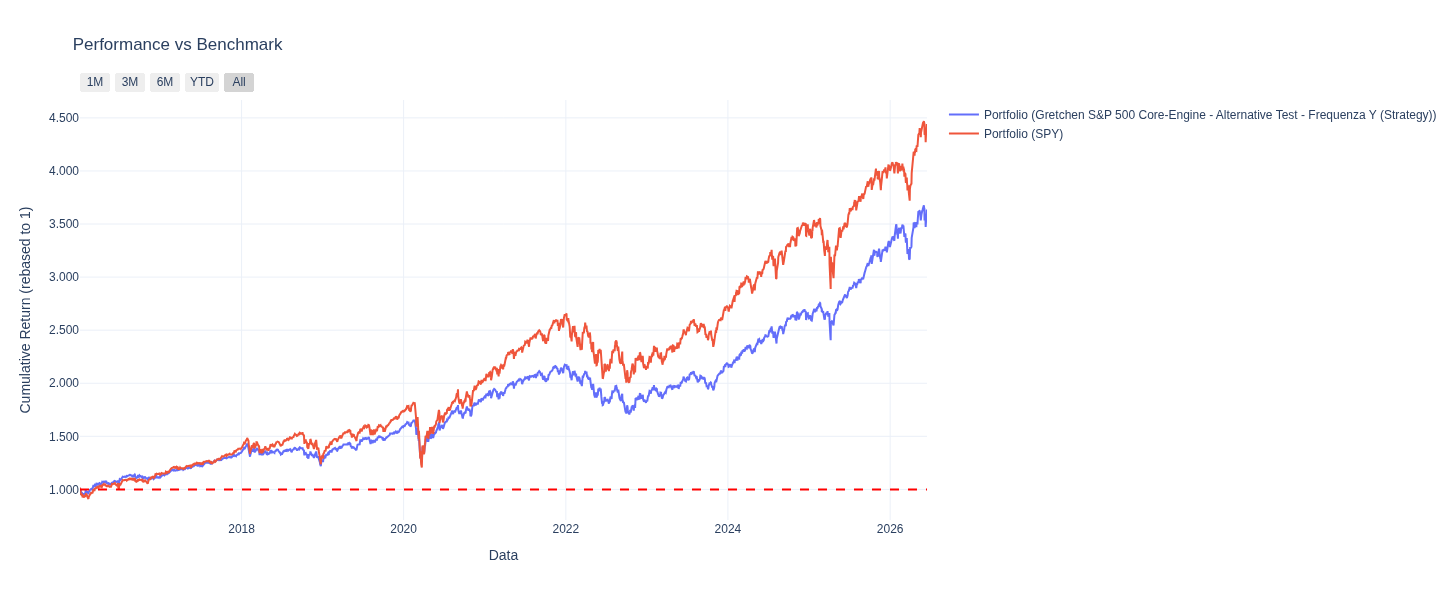

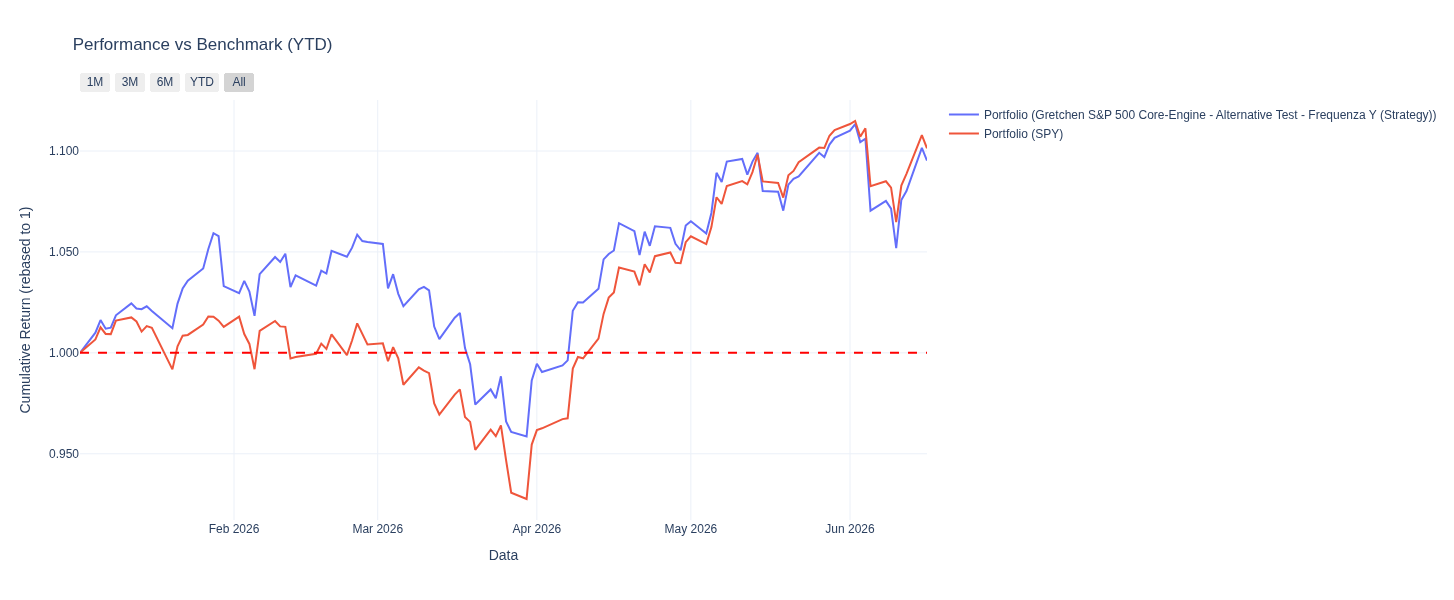

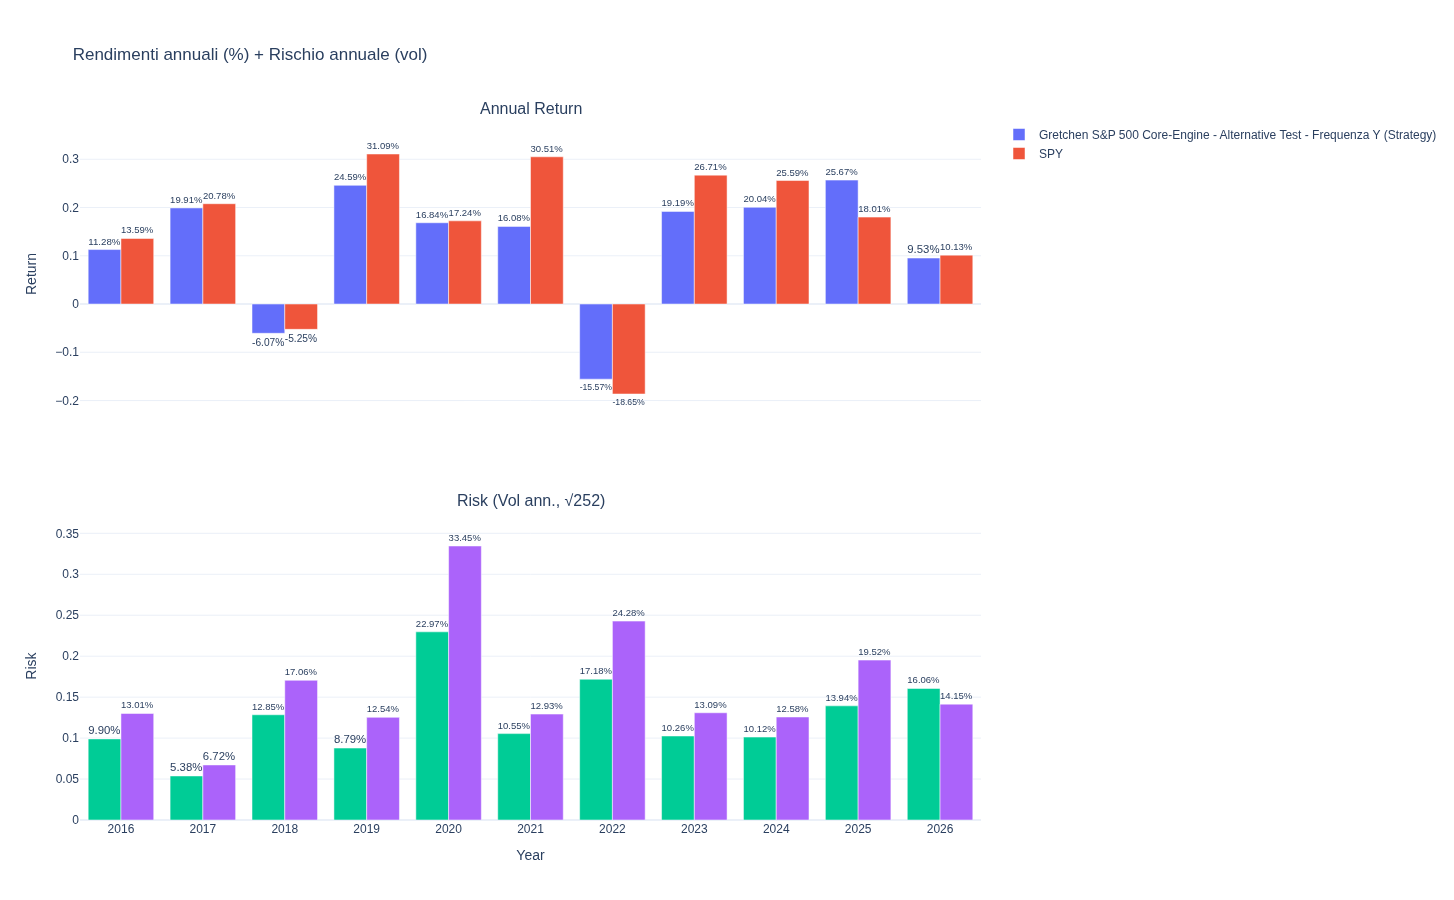

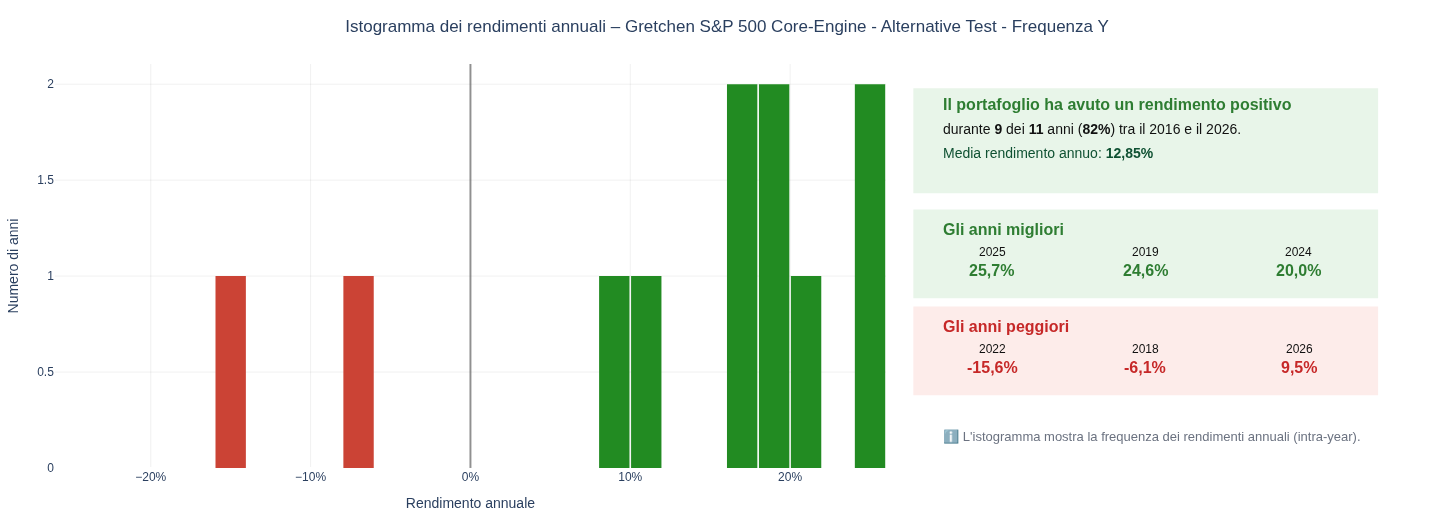

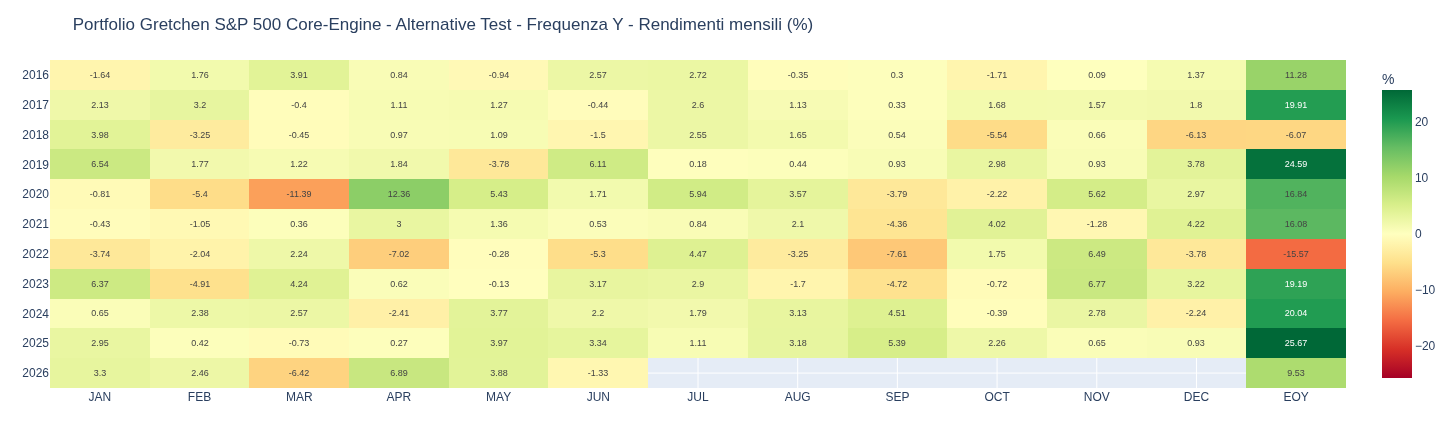

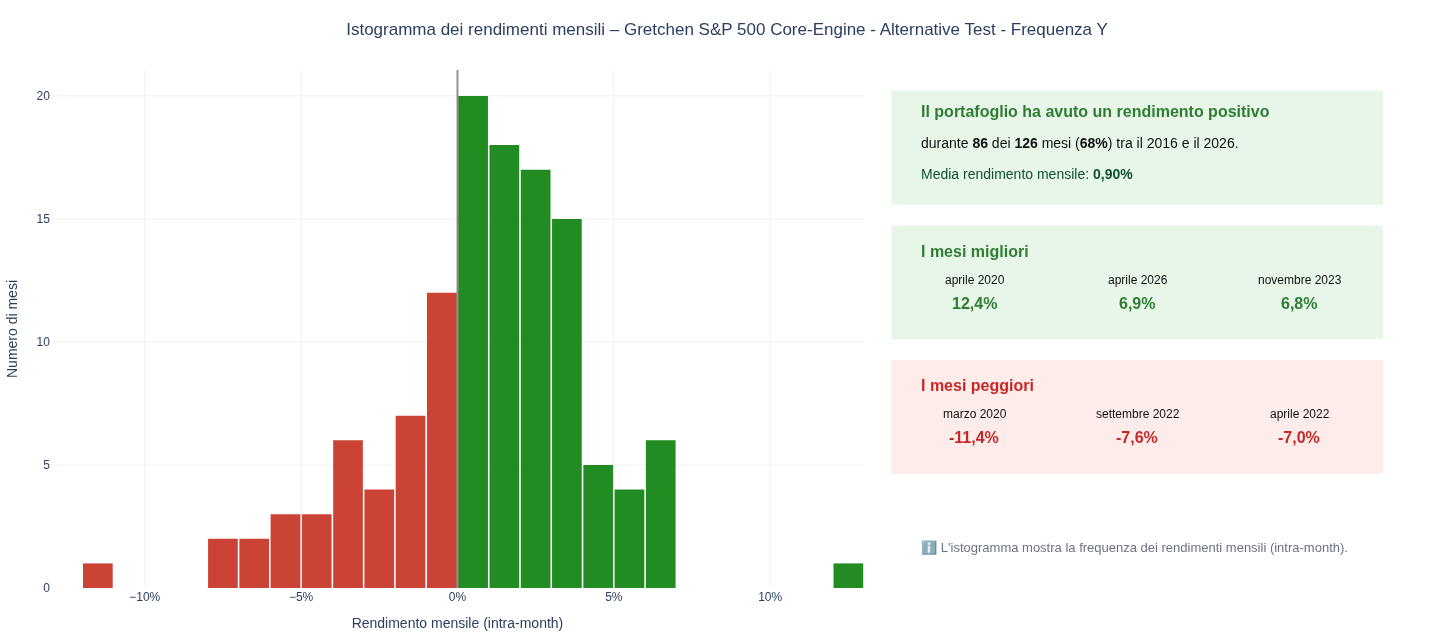

,Orizzonte,Trading_days,Best_start,Best_end,Best_return,Worst_start,Worst_end,Worst_return
0,1y,252,2020-03-23,2021-03-22,51.10,2021-11-04,2022-11-03,-18.26
1,2y,504,2023-10-30,2025-10-31,67.12,2021-10-27,2023-10-27,-8.45
2,3y,756,2022-10-17,2025-10-21,88.31,2017-03-21,2020-03-20,5.98
3,4y,1008,2022-05-23,2026-05-29,95.25,2016-03-22,2020-03-23,19.05
4,5y,1260,2020-03-24,2025-03-27,111.97,2017-10-13,2022-10-14,31.68


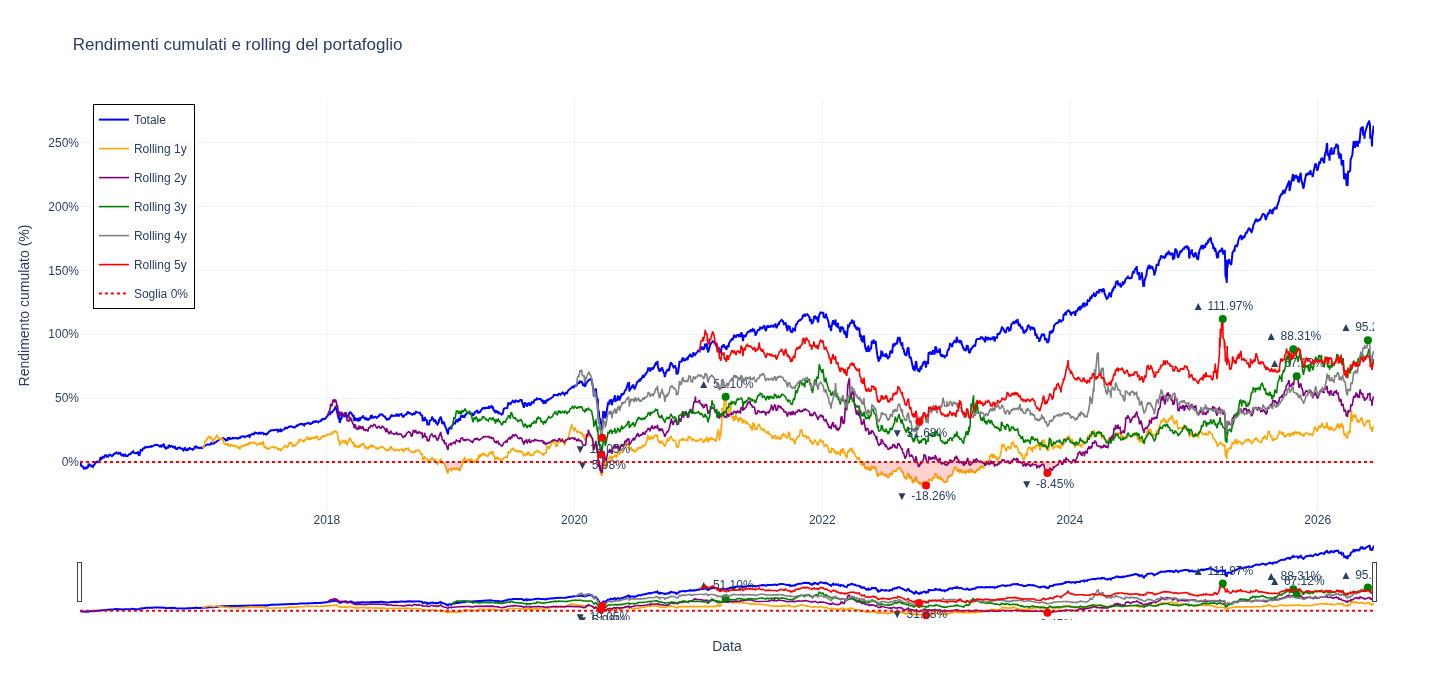

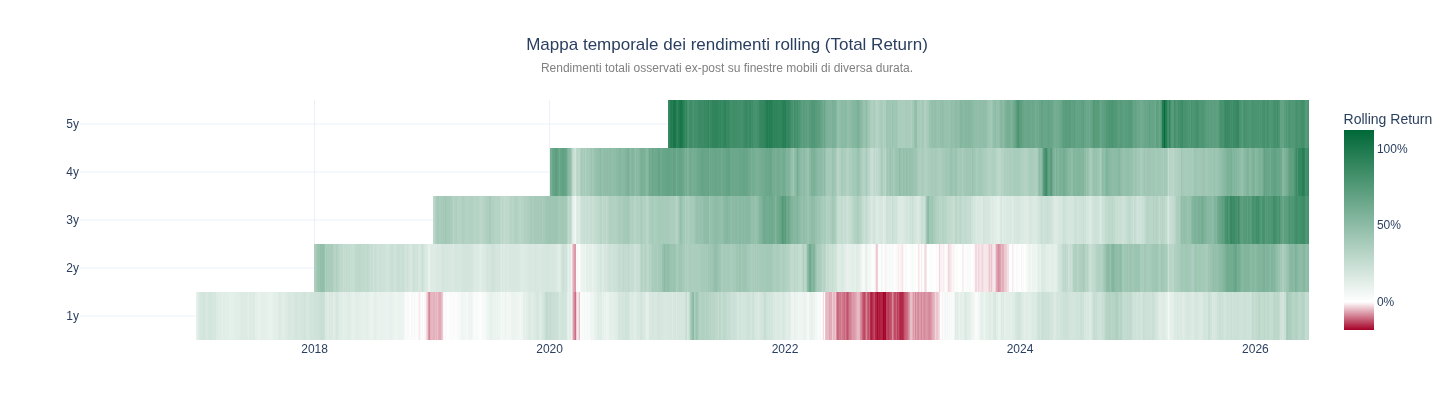

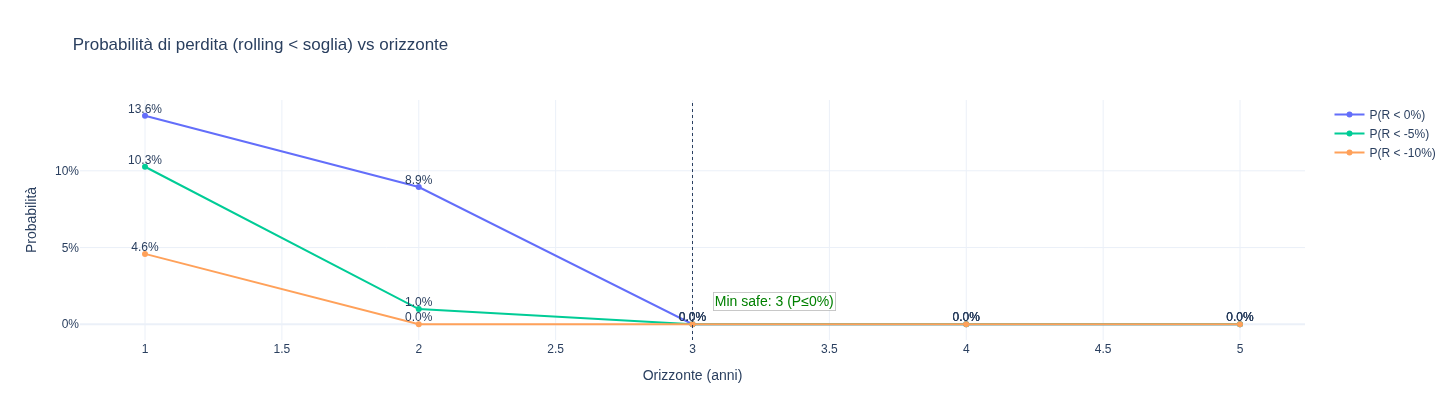

Triangolo dei rendimenti medi annualizzati (CAGR).
Analisi ex-post su finestre discrete di ingresso e uscita.
La valutazione dell’orizzonte minimo di investimento è fornita dalla mappa rolling e dalla curva di probabilità di perdita.


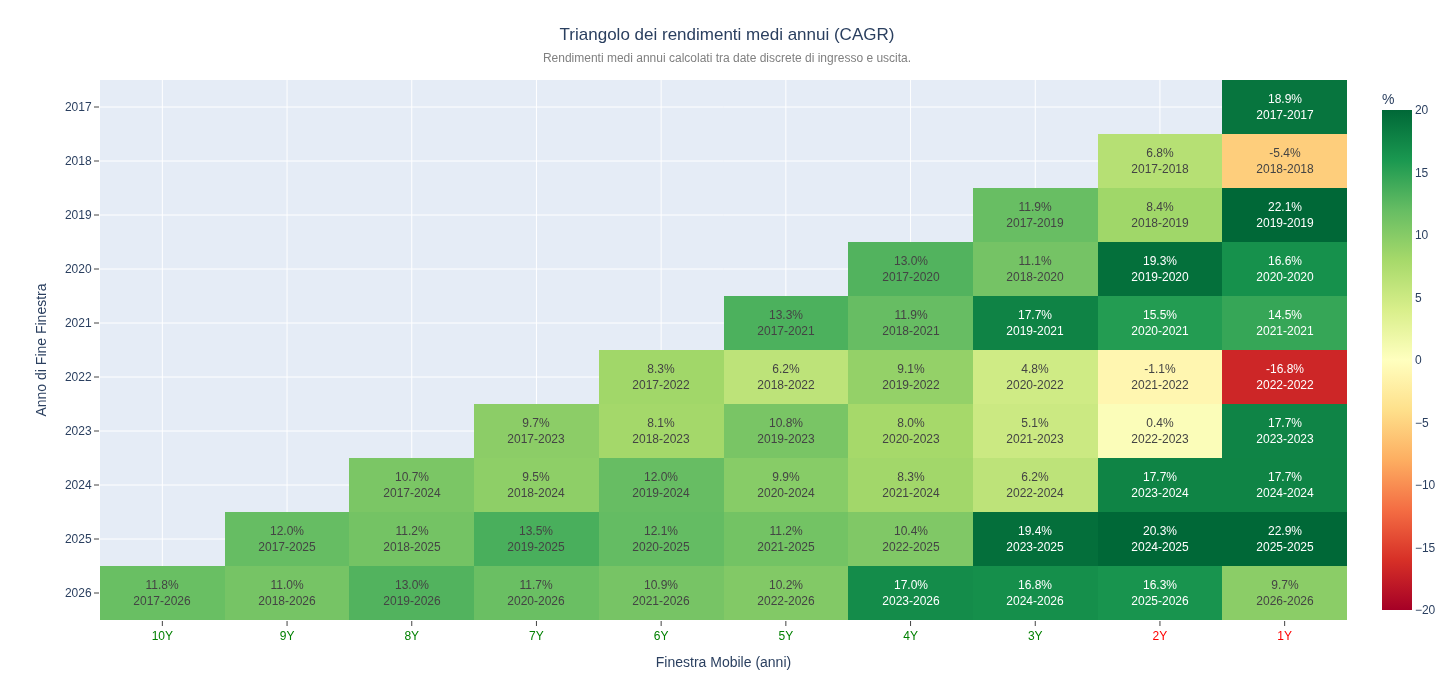

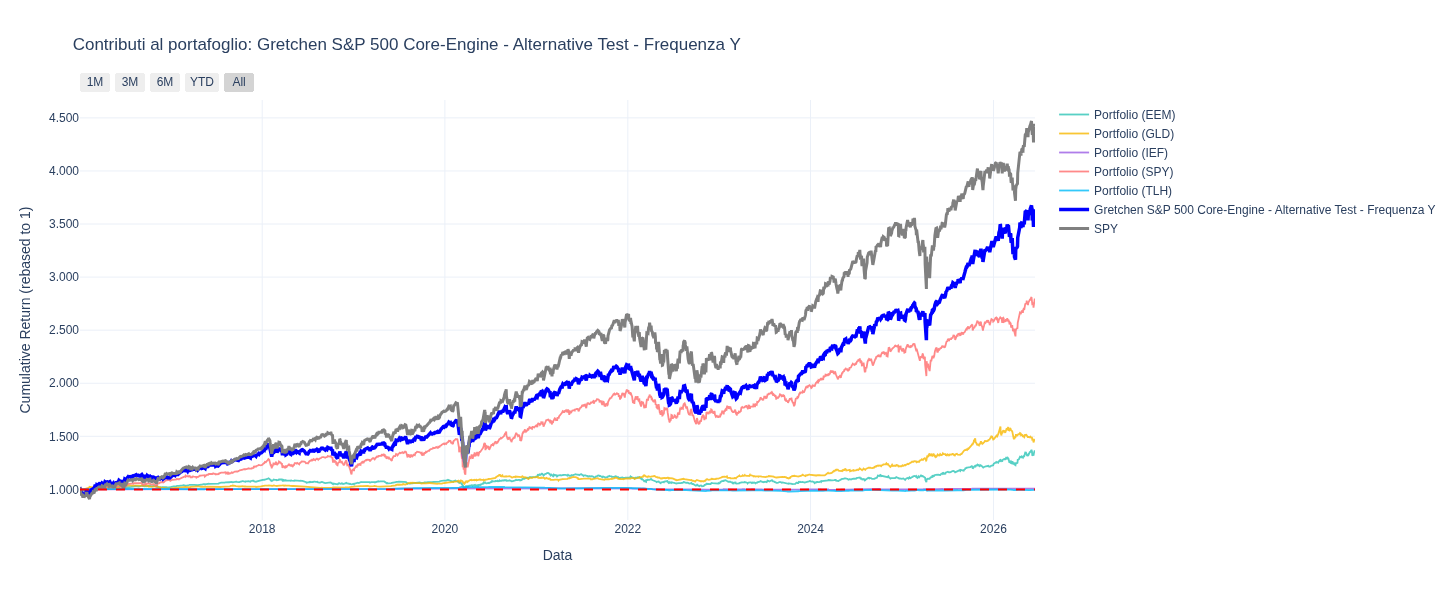

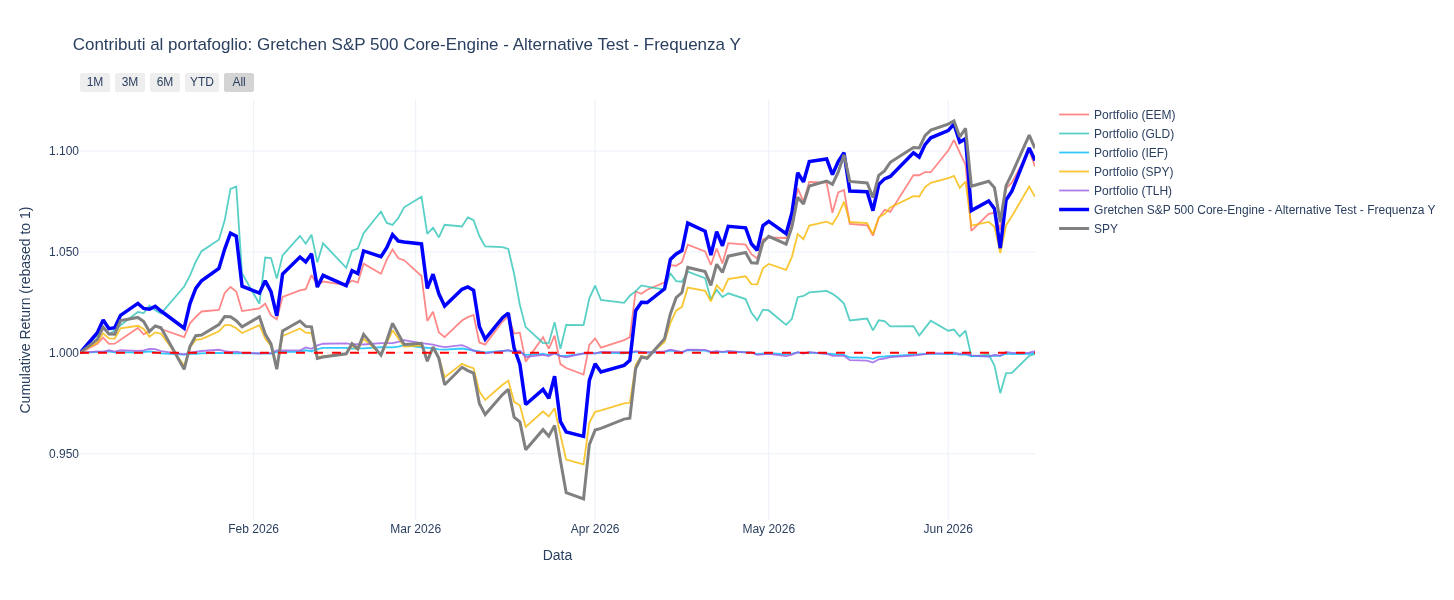

Ticker     EEM    GLD   IEF    SPY   TLH  CASH
Year                                          
2016     14.85  15.37  5.06  59.75  4.97  0.00
2017     15.20  14.90  4.48  59.74  4.97  0.71
2018     15.24  14.96  4.90  60.01  4.89  0.00
2019     13.51  14.90  4.97  60.08  4.96  1.58
2020     13.84  14.49  4.34  59.80  5.04  2.49
2021     15.29  15.09  4.95  59.80  4.87  0.00
2022     12.51  12.46  4.18  59.96  4.94  5.96
2023     15.48  15.03  5.05  59.32  5.12  0.00
2024     13.63  14.25  4.38  59.91  5.01  2.84
2025     14.56  14.89  3.60  60.26  4.92  1.77
2026     15.36  15.30  4.90  59.55  4.89  0.00
CURRENT  15.00  15.00  5.00  60.00  5.00  0.00
                                     Value
Cash mean (%)                        1.465
Cash median (%)                      0.677
Cash max (%)                         7.475
Cash p90 (%)                         2.922
Cash p95 (%)                         6.690
Cash p99 (%)                         7.165
Days cash > 0.5%                  1509.00

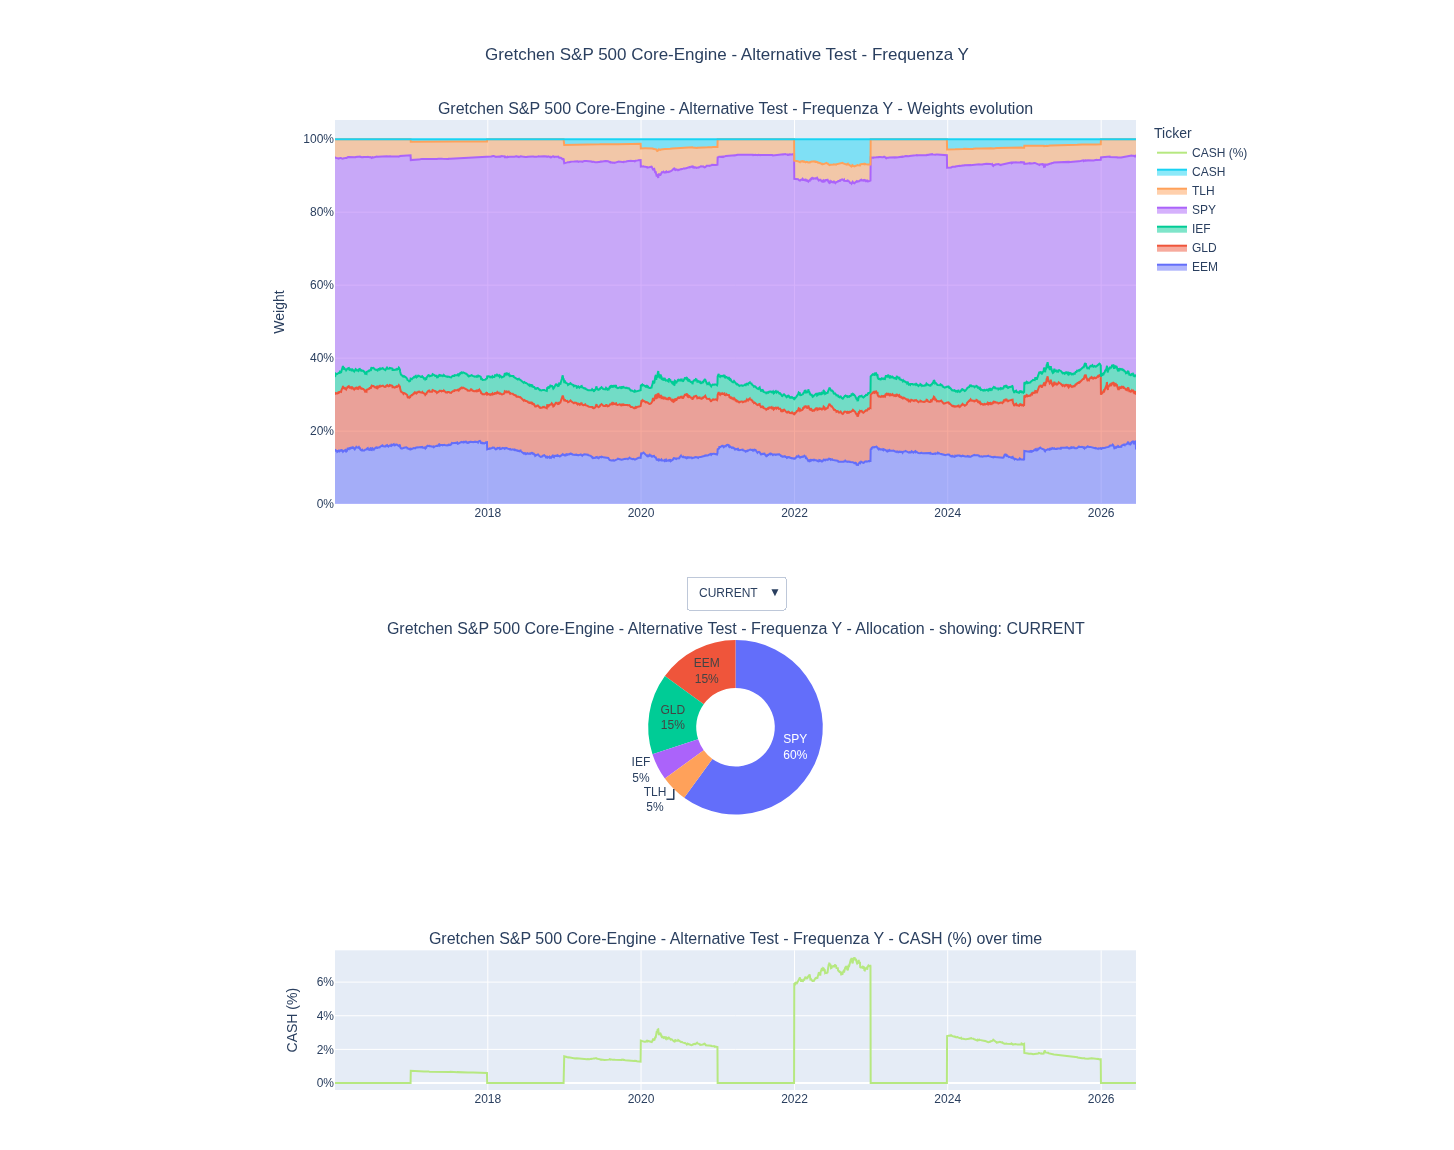

In [31]:
benchmark_data = download_data(benchmark, start_date, end_date)

pf_proposed = run_bh_backtest(my_portfolio, start_date, end_date,
                               init_cash, fees, best_freq)

portfolio_title = f"{my_portfolio_title} - Frequenza {best_freq}"

_ = generate_lazy_portfolio_performance(
    pf=pf_proposed,
    portfolio_title=portfolio_title,
    benchmark=benchmark,
    benchmark_data=benchmark_data,
    show_report=True,
    show_plots=True,
    alpha_analysis=True,
)

## §5 — Perché non adottiamo i pesi "ottimali" della frontiera

Il punto Max Sharpe calcolato in §3 massimizza lo Sharpe ratio
**sullo stesso campione storico** usato per stimarlo (rendimenti
attesi `mu` e covarianza `S` di PyPortfolioOpt). È l'equivalente di
un WFO con un solo fold in-sample e zero fold out-of-sample —
esattamente la trappola che il framework R-portfolio e K-strategy è
costruito per evitare.

In pratica: `mu` (rendimento atteso storico) è il parametro più
instabile e meno affidabile della teoria di Markowitz. I pesi
ottimali calcolati su un campione spesso non reggono fuori campione,
e talvolta perdono anche contro allocazioni banali (equal-weight,
60/40).

**Uso corretto della frontiera**: diagnostico (§3), non prescrittivo.
Se il PTF proposto è molto sotto la frontiera, è un segnale per
rivedere la diversificazione — non per copiare i pesi del punto
Max Sharpe.

La validazione statistica in §6 si applica quindi al **PTF reale
dell'utente** (`pf_proposed`), non ai pesi teorici della frontiera.

## §6 — Validazione statistica

Applicata al PTF reale dell'utente (pf_proposed), non ai pesi teorici
della frontiera. Stability pesi · MC Block A (confidence intervals) ·
MC Block B (skill ribilanciamento) · DSR · Decisione finale.

### §6.1 — Stability test pesi ottimali della frontiera (solo come misura di rumore)

Nota: questo test misura quanto è rumorosa la frontiera stessa
(quanto cambiano i suoi pesi Max Sharpe tra sotto-periodi) — NON
valida i pesi del mio PTF. Un CV alto qui conferma che il punto
Max Sharpe di §3 non va preso come riferimento di allocazione.

In [32]:
stability = lazy_stability_weights(
    tickers=my_tickers,
    years=years,
    weight_bounds=(0, 1),
    n_splits=5,
    verbose=True,
)
print(f"\nRumorosità frontiera: {'bassa ✅' if stability['stable'] else 'alta ⚠️ (conferma: non adottare Max Sharpe come pesi)'}"
      f" (CV medio={stability['cv_mean']:.3f}, soglia={stability['cv_threshold']})")

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed


Stability test pesi — window=2y, splits=5


,EEM,GLD,IEF,SPY,TLH
W1 (2016-2018),0.0,0.2198,0.0000,0.5640,0.2162
W2 (2018-2020),0.0,0.0251,0.7518,0.2231,0.0000
W3 (2020-2022),0.0,0.0334,0.7242,0.2424,0.0000
W4 (2022-2024),0.0,0.9895,0.0000,0.0105,0.0000
W5 (2024-2026),0.0,0.5618,0.1623,0.2760,0.0000


,mean,std,cv
asset,,,
SPY,0.26320,0.197827,0.751623
EEM,0.00000,0.000000,NaN
GLD,0.36592,0.410883,1.122877
IEF,0.32766,0.380528,1.161349
TLH,0.04324,0.096688,2.236068


CV medio: 1.318 — INSTABILE ⚠️

Rumorosità frontiera: alta ⚠️ (conferma: non adottare Max Sharpe come pesi) (CV medio=1.318, soglia=0.5)


In [33]:
# print(stability['df_weights'])

### §6.2 — Monte Carlo Block A: Confidence Intervals sul PTF reale

Stima la distribuzione delle metriche (CAGR, Sharpe, MaxDD) di
pf_proposed via bootstrap.
- **A1 IID**: baseline, campiona ritorni indipendenti
- **A2 Block**: metodo principale, preserva autocorrelazione

In [34]:
_rng = np.random.default_rng(42)
_n_sim = 1000
_block_size = 20  # ~1 mese trading

print("=== A1 — IID Bootstrap ===")
mc_a1 = mc_run_iid_bootstrap(pf_proposed, n_simulations=_n_sim, rng=_rng)

print("\n=== A2 — Block Bootstrap ===")
_rng2 = np.random.default_rng(42)
mc_a2 = mc_run_block_bootstrap(pf_proposed, block_size=_block_size,
                                  n_simulations=_n_sim, rng=_rng2)

print("\n--- Confidence Intervals (A2 Block Bootstrap) — PTF reale ---")
for metric in ['CAGR', 'Sharpe', 'MaxDD']:
    p5  = mc_a2['percentiles']['p5'][metric]
    p50 = mc_a2['percentiles']['p50'][metric]
    p95 = mc_a2['percentiles']['p95'][metric]
    act = mc_a2['actual_metrics'][metric]
    print(f"  {metric:8s}: actual={act:.3f}  p5={p5:.3f}  p50={p50:.3f}  p95={p95:.3f}")

=== A1 — IID Bootstrap ===
  [A1 sanity] median_CAGR=0.132  actual_CAGR=0.131  bias=+0.0012 (should be ≈ 0)

=== A2 — Block Bootstrap ===
  [A2 sanity] std_CAGR=0.0431  (block_size=20; confronta con A1 — A2 dovrebbe avere std >= A1)

--- Confidence Intervals (A2 Block Bootstrap) — PTF reale ---
  CAGR    : actual=0.131  p5=0.061  p50=0.132  p95=0.205
  Sharpe  : actual=1.001  p5=0.491  p50=1.011  p95=1.581
  MaxDD   : actual=-0.242  p5=-0.353  p50=-0.215  p95=-0.129


### §6.3 — Monte Carlo Block B: Skill del ribilanciamento

Testa se la frequenza scelta in §2 per il MIO PTF aggiunge valore
vs date di ribilanciamento randomizzate (jitter ±30 giorni).
p-value < 0.05 → skill significativa.

In [35]:
mc_b = lazy_mc_block_b_rebalancing(
    portfolio=my_portfolio,
    start_date=start_date,
    end_date=end_date,
    best_freq=best_freq,
    n_simulations=500,
    jitter_days=30,
    init_cash=init_cash,
    fees=fees,
    verbose=True,
)

MC Block B — Rebalancing Skill Test
  PTF reale  : Sharpe=1.204  CAGR=13.12%
  Sim median : Sharpe=1.129  CAGR=11.94%
  p-value Sharpe=0.308  p-value CAGR=0.368
  Skill: ⚠️ NO (p>=0.05)


### §6.4 — DSR: Deflated Sharpe Ratio del PTF reale

Valida la significatività statistica dello Sharpe ratio di pf_proposed.
DSR > 0 → Sharpe statisticamente significativo dopo correzione
per multiple testing.

In [36]:
_sr  = float(pf_proposed.sharpe_ratio())
_T   = int(pf_proposed.value().dropna().__len__())
_dsr = ofc_compute_dsr(sr_hat=_sr, n_trials=1, T=_T)
print(f"Sharpe ratio  : {_sr:.3f}")
print(f"T (obs)       : {_T}")
print(f"DSR           : {_dsr:.3f}  {'✅ significativo' if _dsr > 0 else '⚠️ non significativo'}")

Sharpe ratio  : 1.204
T (obs)       : 2628
DSR           : 1.204  ✅ significativo


### §6.5 — Decisione finale

Valuta il PTF reale dell'utente (pesi e frequenza scelti in §1-§2),
non i pesi teorici della frontiera.

In [37]:
cornice = max(65,len(portfolio_title)+10)

print("=" * cornice)
print(f"  LAZY PORTFOLIO — DECISIONE FINALE")
print(f"  {portfolio_title}")
print("=" * cornice)

_checks = {
    'MC A2 Sharpe p50>0'  : mc_a2['percentiles']['p50']['Sharpe'] > 0,
    'MC B skill rebalance': mc_b['skill'],
    'DSR > 0'             : _dsr > 0,
}
_passed = sum(_checks.values())
for label, ok in _checks.items():
    print(f"  {'✅' if ok else '❌'}  {label}")
print("-" * cornice)
print(f"  Criteri superati: {_passed}/{len(_checks)}")
print(f"  Verdetto: {'✅ PROMOSSO' if _passed >= 2 else '❌ RIGETTATO'}")
print("=" * cornice)

  LAZY PORTFOLIO — DECISIONE FINALE
  Gretchen S&P 500 Core-Engine - Alternative Test - Frequenza Y
  ✅  MC A2 Sharpe p50>0
  ❌  MC B skill rebalance
  ✅  DSR > 0
-----------------------------------------------------------------------
  Criteri superati: 2/3
  Verdetto: ✅ PROMOSSO
